# CFN07 — Validation Audit Notebook
**Paper:** Measurement Theory Foundations for VDM: Decoherence, Einselection, and Born Rule Emergence

This notebook is a reviewer-facing audit surface for **CF07**.  
It is not a paper archive. The full TeX sources are **not embedded here**.  
Only the compact claim contract, source provenance digests, executable attacks, pass/fail gates, and the final results ledger are included.


## M0 — Compact manifest integrity

**Plain-language view**

Before any claim is attacked, the notebook checks that the publication-facing manifest is complete enough to define the audit burden without dumping the full paper into the notebook.

**What this cell checks**

- compact paper identity and provenance digests are present
- all declared claims carry the fields needed for a real audit cell
- every declared claim promises a figure, terminal log, and result metrics
- the notebook carries the advertised paper-level gates `G1–G4`

**Pass / fail rule**

Pass only if the compact manifest is structurally complete and reviewer-usable.


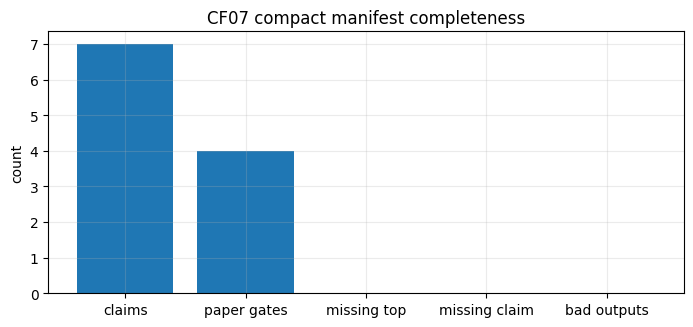

[M0] Compact manifest integrity
- status: ✅ PASS
- criteria:
    * top_level_missing_count: 0
    * claims_declared: >= 6
    * claims_with_missing_fields: 0
    * empty_statement_count: 0
    * empty_honesty_count: 0
    * empty_scope_count: 0
    * empty_figure_spec_count: 0
    * empty_metric_list_count: 0
    * bad_output_promise_count: 0
    * paper_validation_gate_count: >= 4
    * provenance_digest_complete: True
- metrics:
    * top_level_missing_count: 0
    * claims_declared: 7
    * claims_with_missing_fields: 0
    * empty_statement_count: 0
    * empty_honesty_count: 0
    * empty_scope_count: 0
    * empty_figure_spec_count: 0
    * empty_metric_list_count: 0
    * bad_output_promise_count: 0
    * paper_validation_gate_count: 4
    * provenance_digest_complete: True
- notes: Publication notebook carries claim contracts and provenance digests only; full paper text is intentionally omitted.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List
import math
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp")

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=10, suppress=True)

@dataclass
class GateResult:
    gate_id: str
    gate_name: str
    passed: bool
    metrics: Dict[str, Any]
    pass_criteria: Dict[str, Any]
    notes: str

LEDGER: List[GateResult] = []

def terminal_log(gate_id: str, title: str, passed: bool, metrics: Dict[str, Any], criteria: Dict[str, Any], notes: str = "") -> None:
    status_symbol = "✅" if passed else "❌"
    print("=" * 88)
    print(f"[{gate_id}] {title}")
    print("- status:", f"{status_symbol} {'PASS' if passed else 'FAIL'}")
    print("- criteria:")
    for k, v in criteria.items():
        print(f"    * {k}: {v}")
    print("- metrics:")
    for k, v in metrics.items():
        print(f"    * {k}: {v}")
    if notes:
        print("- notes:", notes)
    print("=" * 88)

def record_gate(gate_id: str, gate_name: str, passed: bool, metrics: Dict[str, Any], criteria: Dict[str, Any], notes: str = "") -> None:
    terminal_log(gate_id, gate_name, passed, metrics, criteria, notes=notes)
    LEDGER.append(GateResult(gate_id, gate_name, passed, metrics, criteria, notes))

PAPER_SPEC = {'paper_id': 'CF07',
 'paper_title': 'Measurement Theory Foundations for VDM: Decoherence, Einselection, and Born Rule Emergence',
 'primitive_driver_id': 'A(-1)',
 'source_provenance': {'primitive_driver': {'filename': 'A(-1).tex',
                                            'sha256': '2359c5150436fe3f38b1fea7ff6fe3614dd90760e789e549295524fd01f0768a',
                                            'bytes': 63363,
                                            'lines': 1911},
                       'paper_source': {'filename': 'CF07.tex',
                                        'sha256': '94615d0129b4e66e702fecb282d3ee1bef10ce85a8a1ed7636095f667dfdde7b',
                                        'bytes': 27567,
                                        'lines': 442}},
 'paper_validation_gates': [{'gate_id': 'G1',
                             'description': 'Einselection residual: max_i ||[H_SE, Pi_i]|| <= eps_ein.'},
                            {'gate_id': 'G2',
                             'description': 'Decoherence threshold: trace distance to the dephased state '
                                            'drops below eps_dec after tau_dec.'},
                            {'gate_id': 'G3',
                             'description': 'Target M6 Born frequency meter: KL(f||p) <= eps_KL at declared '
                                            'N and seed suite.'},
                            {'gate_id': 'G4',
                             'description': 'Robustness: small perturbations to H_SE induce only small '
                                            'pointer-basis and Born-weight drift.'}],
 'claims': [{'claim_id': 'C1',
             'canon_anchor': '§2 / Claim C1; §3.3; Gate G1',
             'plain_language_claim': 'A basis only counts as a pointer basis if the interaction really '
                                     "preserves it. If the commutator stays large, the paper's pointer-basis "
                                     'claim fails.',
             'claim_type': 'operator_property',
             'statement': 'A pointer basis is operationally established only when max_i ||[H_SE, Pi_i]|| <= '
                          'eps_ein for the candidate projectors.',
             'attack_mode': 'exact residual norm + negative control + basis-rotation sweep',
             'attack_honesty': 'This attack measures the advertised commutator residual directly and then '
                               'rotates the basis away from the claimed pointer basis to see whether the '
                               'residual rises as it should.',
             'pass_criteria': {'true_basis_residual_max': '<= 1e-12',
                               'x_basis_residual_max': '>= 0.9',
                               'argmin_theta_abs': '<= 1e-12'},
             'fail_signature': 'Residual does not minimize at the claimed basis or the wrong basis is not '
                               'visibly worse.',
             'cannot_prove': 'This cell proves the gate logic on a concrete mechanism; it does not prove '
                             'that every real physical detector realizes this Hamiltonian.',
             'figure_spec': 'Residual versus basis-rotation angle, with the true pointer basis and a wrong '
                            'basis marked.',
             'result_metrics': ['true_basis_residual_max', 'x_basis_residual_max', 'argmin_theta_abs'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'},
            {'claim_id': 'C2',
             'canon_anchor': '§2 / Claim C2; §3.2-3.4; Gate G2',
             'plain_language_claim': 'If decoherence is real for the mechanism under test, off-diagonal '
                                     'coherence should actually die away in time and stay below the '
                                     'threshold after crossing it.',
             'claim_type': 'falsifier',
             'statement': 'The reduced state obeys D(t) = 1/2 ||rho_S(t)-Delta_Pi(rho_S(t))||_1 <= eps_dec '
                          'for t >= tau_dec.',
             'attack_mode': 'exact channel formula + time-series residual + negative control',
             'attack_honesty': 'This attack uses an exact dephasing channel where the trace-distance curve '
                               'is known, checks the threshold crossing, and compares it to a no-decoherence '
                               'control that should fail.',
             'pass_criteria': {'trace_formula_residual_max': '<= 1e-12',
                               'tau_error_abs': '<= 5e-3',
                               'control_crosses_threshold': False},
             'fail_signature': 'Trace-distance curve does not match the channel formula, threshold time is '
                               'wrong, or the no-decoherence control also passes.',
             'cannot_prove': 'This cell validates the gate on a declared CPTP mechanism; it does not solve '
                             'the single-outcome problem.',
             'figure_spec': 'Trace distance versus time for the true dephasing channel and the '
                            'no-decoherence control.',
             'result_metrics': ['trace_formula_residual_max', 'tau_error_abs', 'control_crosses_threshold'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'},
            {'claim_id': 'B1',
             'canon_anchor': '§4.3 Theorem (Born rule as unique solution of the symmetry constraints)',
             'plain_language_claim': 'Inside the power-law family forced by multiplicativity and regularity, '
                                     'additivity should pick out only F(x)=x. If another exponent also '
                                     "works, the theorem's key narrowing step is broken.",
             'claim_type': 'algebraic_identity',
             'statement': 'Within F(x)=x^alpha, the additivity constraint F(x)+F(1-x)=1 for all x in [0,1] '
                          'has the unique solution alpha=1.',
             'attack_mode': 'parameter sweep + exact residual norm + negative controls',
             'attack_honesty': 'This attacks the load-bearing executable part of the proof sketch: after '
                               'multiplicativity reduces the family to powers, additivity should leave only '
                               'alpha = 1.',
             'pass_criteria': {'alpha_star_abs_error': '<= 5e-3',
                               'additivity_residual_at_alpha_star': '<= 1e-12',
                               'control_residual_min': '>= 1e-2'},
             'fail_signature': 'The minimum does not occur at alpha = 1 or nearby wrong exponents also '
                               'satisfy additivity.',
             'cannot_prove': 'This cell does not independently re-derive the power-law family from '
                             'continuity and multiplicativity; it audits the narrowing step the paper '
                             'actually uses.',
             'figure_spec': 'Additivity residual as a function of the power exponent alpha.',
             'result_metrics': ['alpha_star_abs_error',
                                'additivity_residual_at_alpha_star',
                                'control_residual_min'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'},
            {'claim_id': 'CG1',
             'canon_anchor': '§5.1-5.2 finite-resolution coarse graining',
             'plain_language_claim': 'If coarse resolution is really what washes out interference, a top-hat '
                                     'window should suppress an oscillatory term exactly by the advertised '
                                     'sinc factor.',
             'claim_type': 'differential_identity',
             'statement': 'For a top-hat window of width Delta x, the coarse-grained interference factor is '
                          'sinc(Delta k Delta x / 2), which becomes small when Delta k Delta x is large.',
             'attack_mode': 'direct numerical quadrature + exact formula residual + asymptotic suppression '
                            'check',
             'attack_honesty': 'This cell computes the window average directly and checks it against the '
                               "paper's analytic formula over a wide parameter sweep.",
             'pass_criteria': {'formula_residual_max': '<= 5e-5', 'max_tail_suppression_after_36': '<= 5e-2'},
             'fail_signature': 'The numerical window average disagrees with the sinc formula or the '
                               'large-separation suppression never appears.',
             'cannot_prove': 'This cell proves the advertised windowing formula for the chosen detector '
                             'kernel; it does not prove that all laboratory detectors are top-hat windows.',
             'figure_spec': 'Magnitude of the coarse-grained interference factor versus the dimensionless '
                            'product Delta k Delta x.',
             'result_metrics': ['formula_residual_max', 'max_tail_suppression_after_36'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Supporting'},
            {'claim_id': 'C3',
             'canon_anchor': '§2 / Claim C3; §7.1; Gate G3',
             'plain_language_claim': 'If the Born-frequency meter is honest, repeated samples from the '
                                     'correct Born weights should usually pass the KL threshold while '
                                     'samples from the wrong law should fail.',
             'claim_type': 'falsifier',
             'statement': 'At declared N and seed suite, KL(f||p) <= eps_KL for the correct sampler, with '
                          'systematic deviations falsifying the meter.',
             'attack_mode': 'seed sweep + KL gate + adversarial wrong-sampler negative control',
             'attack_honesty': "This is the paper's own meter turned into an attack: many seeds for the true "
                               'distribution, then a nearby wrong distribution to make sure the gate has '
                               'bite.',
             'pass_criteria': {'true_pass_fraction': '>= 0.95',
                               'median_true_kl': '<= 1e-3',
                               'median_wrong_kl': '>= 1e-2'},
             'fail_signature': 'True samples frequently fail or the wrong sampler sneaks through the same '
                               'gate.',
             'cannot_prove': 'This cell validates the meter on a declared multinomial model; it does not '
                             'prove every physical apparatus is i.i.d.',
             'figure_spec': 'KL histograms for the true Born sampler and a nearby wrong sampler.',
             'result_metrics': ['true_pass_fraction', 'median_true_kl', 'median_wrong_kl'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'},
            {'claim_id': 'C4',
             'canon_anchor': '§2 / Claim C4; §7.2-7.3',
             'plain_language_claim': 'The expected KL divergence should fall like (d-1)/(2N). If the '
                                     "empirical mean scales differently, the paper's planning law is wrong.",
             'claim_type': 'scaling_prediction',
             'statement': 'In the large-N regime, E[KL(f||p)] ~ (d-1)/(2N).',
             'attack_mode': 'sample-size sweep + Monte Carlo mean + log-log slope check + wrong-scaling '
                            'negative control',
             'attack_honesty': 'This cell attacks both the absolute prefactor and the 1/N scaling, then '
                               'compares it to an obviously wrong 1/N^2 law.',
             'pass_criteria': {'loglog_slope': 'between -1.1 and -0.9',
                               'max_relative_error_to_prediction': '<= 0.1',
                               'wrong_scaling_sse_ratio': '>= 10'},
             'fail_signature': 'The empirical mean does not scale like 1/N or the prefactor misses badly.',
             'cannot_prove': 'This cell is still a finite Monte Carlo study; it does not replace an '
                             'asymptotic theorem proof.',
             'figure_spec': 'Empirical mean KL versus N overlaid with the (d-1)/(2N) prediction.',
             'result_metrics': ['loglog_slope',
                                'max_relative_error_to_prediction',
                                'wrong_scaling_sse_ratio'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'},
            {'claim_id': 'R1',
             'canon_anchor': '§8 Gate G4 robustness under perturbations',
             'plain_language_claim': 'A measurement channel that falls apart under tiny perturbations is not '
                                     'a usable instrument. Small Hamiltonian tilts should cause only small '
                                     'pointer and probability drift.',
             'claim_type': 'falsifier',
             'statement': 'For ||delta H_SE||/||H_SE|| <= eta, induced changes in pointer projectors and '
                          'Born weights remain within stated tolerances.',
             'attack_mode': 'operator perturbation sweep + projector-drift metric + Born-weight drift metric '
                            '+ large-perturbation negative control',
             'attack_honesty': 'This cell perturbs the measurement coupling continuously, measures both '
                               'basis drift and probability drift, and checks that small tilts stay small '
                               'while a large tilt does not.',
             'pass_criteria': {'small_delta_projector_drift_max': '<= 3e-2',
                               'small_delta_prob_drift_max': '<= 5e-3',
                               'large_delta_prob_drift_min': '>= 5e-2'},
             'fail_signature': 'Tiny perturbations already create large drift or large perturbations are not '
                               'distinguishable from small ones.',
             'cannot_prove': 'This cell validates a concrete perturbative robustness contract, not every '
                             'possible detector architecture.',
             'figure_spec': 'Pointer-projector drift and Born-weight drift versus coupling tilt angle.',
             'result_metrics': ['small_delta_projector_drift_max',
                                'small_delta_prob_drift_max',
                                'large_delta_prob_drift_min'],
             'expected_outputs': ['figure', 'terminal_log', 'result_metrics'],
             'paper_level_relevance': 'Direct'}]}
CLAIM_TO_PAPER_GATES = {'C1': ['G1'], 'C2': ['G2'], 'B1': [], 'CG1': [], 'C3': ['G3'], 'C4': [], 'R1': ['G4']}

required_top = {"paper_id", "paper_title", "primitive_driver_id", "source_provenance", "paper_validation_gates", "claims"}
required_claim = {
    "claim_id", "canon_anchor", "plain_language_claim", "claim_type", "statement", "attack_mode",
    "attack_honesty", "pass_criteria", "fail_signature", "cannot_prove", "figure_spec",
    "result_metrics", "expected_outputs", "paper_level_relevance"
}

missing_top = sorted(list(required_top - set(PAPER_SPEC.keys())))
claim_missing = {}
empty_statement_claims = []
empty_honesty_claims = []
empty_scope_claims = []
empty_figure_claims = []
empty_metrics_claims = []
bad_output_promises = []

for claim in PAPER_SPEC["claims"]:
    cid = claim["claim_id"]
    missing = sorted(list(required_claim - set(claim.keys())))
    if missing:
        claim_missing[cid] = missing
    if not str(claim.get("statement", "")).strip():
        empty_statement_claims.append(cid)
    if not str(claim.get("attack_honesty", "")).strip():
        empty_honesty_claims.append(cid)
    if not str(claim.get("cannot_prove", "")).strip():
        empty_scope_claims.append(cid)
    if len(str(claim.get("figure_spec", "")).strip()) < 12:
        empty_figure_claims.append(cid)
    if not claim.get("result_metrics"):
        empty_metrics_claims.append(cid)
    promised = set(claim.get("expected_outputs", []))
    if not {"figure", "terminal_log", "result_metrics"}.issubset(promised):
        bad_output_promises.append(cid)

prov_ok = (
    "primitive_driver" in PAPER_SPEC["source_provenance"]
    and "paper_source" in PAPER_SPEC["source_provenance"]
    and all("sha256" in PAPER_SPEC["source_provenance"][k] for k in ["primitive_driver", "paper_source"])
)

metrics = {
    "top_level_missing_count": len(missing_top),
    "claims_declared": len(PAPER_SPEC["claims"]),
    "claims_with_missing_fields": len(claim_missing),
    "empty_statement_count": len(empty_statement_claims),
    "empty_honesty_count": len(empty_honesty_claims),
    "empty_scope_count": len(empty_scope_claims),
    "empty_figure_spec_count": len(empty_figure_claims),
    "empty_metric_list_count": len(empty_metrics_claims),
    "bad_output_promise_count": len(bad_output_promises),
    "paper_validation_gate_count": len(PAPER_SPEC["paper_validation_gates"]),
    "provenance_digest_complete": prov_ok,
}
criteria = {
    "top_level_missing_count": 0,
    "claims_declared": ">= 6",
    "claims_with_missing_fields": 0,
    "empty_statement_count": 0,
    "empty_honesty_count": 0,
    "empty_scope_count": 0,
    "empty_figure_spec_count": 0,
    "empty_metric_list_count": 0,
    "bad_output_promise_count": 0,
    "paper_validation_gate_count": ">= 4",
    "provenance_digest_complete": True,
}

fig, ax = plt.subplots(figsize=(8.2, 3.4))
bars = {
    "claims": len(PAPER_SPEC["claims"]),
    "paper gates": len(PAPER_SPEC["paper_validation_gates"]),
    "missing top": len(missing_top),
    "missing claim": len(claim_missing),
    "bad outputs": len(bad_output_promises),
}
ax.bar(list(bars.keys()), list(bars.values()))
ax.set_title("CF07 compact manifest completeness")
ax.set_ylabel("count")
ax.grid(alpha=0.25)
plt.show()

passed = (
    len(missing_top) == 0
    and len(PAPER_SPEC["claims"]) >= 6
    and len(claim_missing) == 0
    and len(empty_statement_claims) == 0
    and len(empty_honesty_claims) == 0
    and len(empty_scope_claims) == 0
    and len(empty_figure_claims) == 0
    and len(empty_metrics_claims) == 0
    and len(bad_output_promises) == 0
    and len(PAPER_SPEC["paper_validation_gates"]) >= 4
    and prov_ok
)
record_gate(
    "M0",
    "Compact manifest integrity",
    passed,
    metrics,
    criteria,
    notes="Publication notebook carries claim contracts and provenance digests only; full paper text is intentionally omitted.",
)


## C1 — §2 / Claim C1; §3.3; Gate G1

**Plain-language claim**

A basis only counts as a pointer basis if the interaction really preserves it. If the commutator stays large, the paper's pointer-basis claim fails.

**Formal statement**

`A pointer basis is operationally established only when max_i ||[H_SE, Pi_i]|| <= eps_ein for the candidate projectors.`

**Attack mode**

exact residual norm + negative control + basis-rotation sweep

**Attack honesty**

This attack measures the advertised commutator residual directly and then rotates the basis away from the claimed pointer basis to see whether the residual rises as it should.

**Pass / fail criteria**

- `true_basis_residual_max`: <= 1e-12
- `x_basis_residual_max`: >= 0.9
- `argmin_theta_abs`: <= 1e-12

**This cell cannot prove**

This cell proves the gate logic on a concrete mechanism; it does not prove that every real physical detector realizes this Hamiltonian.


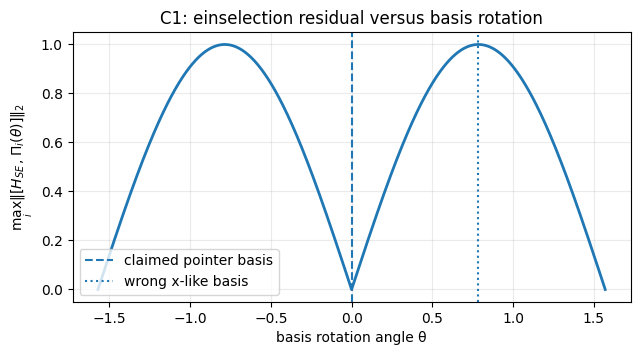

[C1] Pointer stability / einselection residual
- status: ✅ PASS
- criteria:
    * true_basis_residual_max: <= 1e-12
    * x_basis_residual_max: >= 0.9
    * argmin_theta_abs: <= 1e-12
- metrics:
    * true_basis_residual_max: 0.0
    * x_basis_residual_max: 1.0
    * argmin_theta_abs: 0.0
- notes: Covers paper gate G1 on the concrete sigma_z monitoring mechanism.


In [2]:

sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)

def rank1_projectors(theta: float) -> List[np.ndarray]:
    v = np.array([math.cos(theta), math.sin(theta)], dtype=complex)
    p0 = np.outer(v, v.conj())
    p1 = np.eye(2, dtype=complex) - p0
    return [p0, p1]

def commutator_residual(H: np.ndarray, P: np.ndarray) -> float:
    return float(np.linalg.norm(H @ P - P @ H, ord=2))

thetas = np.linspace(-0.5 * np.pi, 0.5 * np.pi, 2001)
residual_curve = np.array(
    [max(commutator_residual(sigma_z, P) for P in rank1_projectors(theta)) for theta in thetas]
)

theta_true = 0.0
theta_x = 0.25 * np.pi
true_basis_residual_max = max(commutator_residual(sigma_z, P) for P in rank1_projectors(theta_true))
x_basis_residual_max = max(commutator_residual(sigma_z, P) for P in rank1_projectors(theta_x))
argmin_theta_abs = float(abs(thetas[int(np.argmin(residual_curve))]))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.plot(thetas, residual_curve, lw=2)
ax.axvline(theta_true, ls="--", label="claimed pointer basis")
ax.axvline(theta_x, ls=":", label="wrong x-like basis")
ax.set_title("C1: einselection residual versus basis rotation")
ax.set_xlabel("basis rotation angle θ")
ax.set_ylabel(r"$\max_i \|[H_{SE},\Pi_i(\theta)]\|_2$")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "true_basis_residual_max": float(true_basis_residual_max),
    "x_basis_residual_max": float(x_basis_residual_max),
    "argmin_theta_abs": argmin_theta_abs,
}
criteria = {
    "true_basis_residual_max": "<= 1e-12",
    "x_basis_residual_max": ">= 0.9",
    "argmin_theta_abs": "<= 1e-12",
}
passed = (
    metrics["true_basis_residual_max"] <= 1e-12
    and metrics["x_basis_residual_max"] >= 0.9
    and metrics["argmin_theta_abs"] <= 1e-12
)
record_gate(
    "C1",
    "Pointer stability / einselection residual",
    passed,
    metrics,
    criteria,
    notes="Covers paper gate G1 on the concrete sigma_z monitoring mechanism.",
)


## C2 — §2 / Claim C2; §3.2-3.4; Gate G2

**Plain-language claim**

If decoherence is real for the mechanism under test, off-diagonal coherence should actually die away in time and stay below the threshold after crossing it.

**Formal statement**

`The reduced state obeys D(t) = 1/2 ||rho_S(t)-Delta_Pi(rho_S(t))||_1 <= eps_dec for t >= tau_dec.`

**Attack mode**

exact channel formula + time-series residual + negative control

**Attack honesty**

This attack uses an exact dephasing channel where the trace-distance curve is known, checks the threshold crossing, and compares it to a no-decoherence control that should fail.

**Pass / fail criteria**

- `trace_formula_residual_max`: <= 1e-12
- `tau_error_abs`: <= 5e-3
- `control_crosses_threshold`: False

**This cell cannot prove**

This cell validates the gate on a declared CPTP mechanism; it does not solve the single-outcome problem.


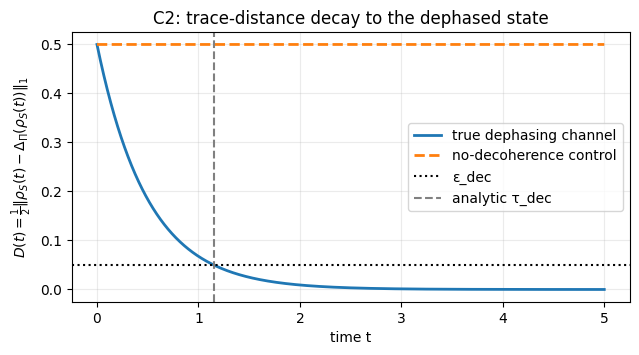

[C2] Decoherence threshold crossing
- status: ✅ PASS
- criteria:
    * trace_formula_residual_max: <= 1e-12
    * tau_error_abs: <= 5e-3
    * control_crosses_threshold: False
- metrics:
    * trace_formula_residual_max: 1.6653345369377348e-16
    * tau_error_abs: 0.0007074535029771845
    * control_crosses_threshold: False
- notes: Covers paper gate G2 using an exact qubit dephasing channel with a no-decoherence negative control.


In [3]:

eps_dec = 5e-2
gamma = 2.0
times = np.linspace(0.0, 5.0, 5001)

a = 1.0 / math.sqrt(2.0)
b = 1.0 / math.sqrt(2.0)
rho0 = np.array([[abs(a) ** 2, a * np.conj(b)], [np.conj(a) * b, abs(b) ** 2]], dtype=complex)
rho_diag = np.diag(np.diag(rho0))

def rho_dephased(t: float, gamma_value: float) -> np.ndarray:
    factor = math.exp(-gamma_value * t)
    return np.array(
        [
            [abs(a) ** 2, a * np.conj(b) * factor],
            [np.conj(a) * b * factor, abs(b) ** 2],
        ],
        dtype=complex,
    )

def trace_distance_to_diag(rho: np.ndarray) -> float:
    delta = rho - np.diag(np.diag(rho))
    svals = np.linalg.svd(delta, compute_uv=False)
    return float(0.5 * np.sum(np.abs(svals)))

D_true = np.array([trace_distance_to_diag(rho_dephased(t, gamma)) for t in times])
D_formula = 0.5 * np.exp(-gamma * times)
D_control = np.array([trace_distance_to_diag(rho_dephased(t, 0.0)) for t in times])

trace_formula_residual_max = float(np.max(np.abs(D_true - D_formula)))
tau_exact = float(math.log(0.5 / eps_dec) / gamma)
tau_numeric = float(times[np.argmax(D_true <= eps_dec)])
tau_error_abs = float(abs(tau_numeric - tau_exact))
control_crosses_threshold = bool(np.any(D_control <= eps_dec))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.plot(times, D_true, label="true dephasing channel", lw=2)
ax.plot(times, D_control, label="no-decoherence control", lw=2, ls="--")
ax.axhline(eps_dec, color="black", ls=":", label="ε_dec")
ax.axvline(tau_exact, color="gray", ls="--", label="analytic τ_dec")
ax.set_title("C2: trace-distance decay to the dephased state")
ax.set_xlabel("time t")
ax.set_ylabel(r"$D(t)=\frac{1}{2}\|\rho_S(t)-\Delta_\Pi(\rho_S(t))\|_1$")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "trace_formula_residual_max": trace_formula_residual_max,
    "tau_error_abs": tau_error_abs,
    "control_crosses_threshold": control_crosses_threshold,
}
criteria = {
    "trace_formula_residual_max": "<= 1e-12",
    "tau_error_abs": "<= 5e-3",
    "control_crosses_threshold": False,
}
passed = (
    metrics["trace_formula_residual_max"] <= 1e-12
    and metrics["tau_error_abs"] <= 5e-3
    and metrics["control_crosses_threshold"] is False
)
record_gate(
    "C2",
    "Decoherence threshold crossing",
    passed,
    metrics,
    criteria,
    notes="Covers paper gate G2 using an exact qubit dephasing channel with a no-decoherence negative control.",
)


## B1 — §4.3 Theorem (Born rule as unique solution of the symmetry constraints)

**Plain-language claim**

Inside the power-law family forced by multiplicativity and regularity, additivity should pick out only F(x)=x. If another exponent also works, the theorem's key narrowing step is broken.

**Formal statement**

`Within F(x)=x^alpha, the additivity constraint F(x)+F(1-x)=1 for all x in [0,1] has the unique solution alpha=1.`

**Attack mode**

parameter sweep + exact residual norm + negative controls

**Attack honesty**

This attacks the load-bearing executable part of the proof sketch: after multiplicativity reduces the family to powers, additivity should leave only alpha = 1.

**Pass / fail criteria**

- `alpha_star_abs_error`: <= 5e-3
- `additivity_residual_at_alpha_star`: <= 1e-12
- `control_residual_min`: >= 1e-2

**This cell cannot prove**

This cell does not independently re-derive the power-law family from continuity and multiplicativity; it audits the narrowing step the paper actually uses.


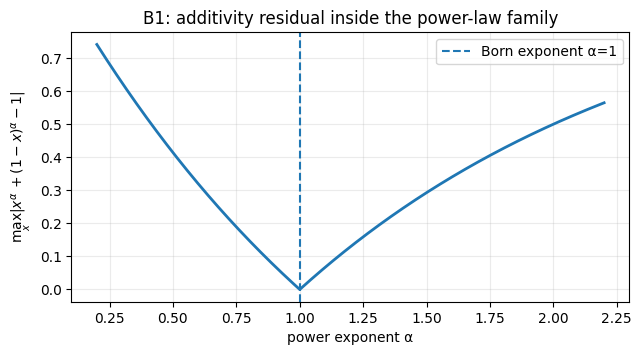

[B1] Born-rule narrowing step inside the power family
- status: ✅ PASS
- criteria:
    * alpha_star_abs_error: <= 5e-3
    * additivity_residual_at_alpha_star: <= 1e-12
    * control_residual_min: >= 1e-2
- metrics:
    * alpha_star_abs_error: 0.0
    * additivity_residual_at_alpha_star: 0.0
    * control_residual_min: 0.12944943670387588
- notes: Direct audit of the theorem's executable narrowing step from x^alpha to alpha = 1.


In [4]:

alphas = np.linspace(0.2, 2.2, 2001)
xs = np.linspace(1e-6, 1.0 - 1e-6, 4001)

def additivity_residual(alpha: float) -> float:
    vals = xs ** alpha + (1.0 - xs) ** alpha - 1.0
    return float(np.max(np.abs(vals)))

residuals = np.array([additivity_residual(alpha) for alpha in alphas])
alpha_star = float(alphas[int(np.argmin(residuals))])
alpha_star_abs_error = float(abs(alpha_star - 1.0))
additivity_residual_at_alpha_star = float(np.min(residuals))
control_exponents = [0.5, 0.8, 1.2, 1.5]
control_residual_min = float(min(additivity_residual(alpha) for alpha in control_exponents))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.plot(alphas, residuals, lw=2)
ax.axvline(1.0, ls="--", label="Born exponent α=1")
ax.set_title("B1: additivity residual inside the power-law family")
ax.set_xlabel("power exponent α")
ax.set_ylabel(r"$\max_x |x^\alpha + (1-x)^\alpha - 1|$")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "alpha_star_abs_error": alpha_star_abs_error,
    "additivity_residual_at_alpha_star": additivity_residual_at_alpha_star,
    "control_residual_min": control_residual_min,
}
criteria = {
    "alpha_star_abs_error": "<= 5e-3",
    "additivity_residual_at_alpha_star": "<= 1e-12",
    "control_residual_min": ">= 1e-2",
}
passed = (
    metrics["alpha_star_abs_error"] <= 5e-3
    and metrics["additivity_residual_at_alpha_star"] <= 1e-12
    and metrics["control_residual_min"] >= 1e-2
)
record_gate(
    "B1",
    "Born-rule narrowing step inside the power family",
    passed,
    metrics,
    criteria,
    notes="Direct audit of the theorem's executable narrowing step from x^alpha to alpha = 1.",
)


## CG1 — §5.1-5.2 finite-resolution coarse graining

**Plain-language claim**

If coarse resolution is really what washes out interference, a top-hat window should suppress an oscillatory term exactly by the advertised sinc factor.

**Formal statement**

`For a top-hat window of width Delta x, the coarse-grained interference factor is sinc(Delta k Delta x / 2), which becomes small when Delta k Delta x is large.`

**Attack mode**

direct numerical quadrature + exact formula residual + asymptotic suppression check

**Attack honesty**

This cell computes the window average directly and checks it against the paper's analytic formula over a wide parameter sweep.

**Pass / fail criteria**

- `formula_residual_max`: <= 5e-5
- `max_tail_suppression_after_36`: <= 5e-2

**This cell cannot prove**

This cell proves the advertised windowing formula for the chosen detector kernel; it does not prove that all laboratory detectors are top-hat windows.


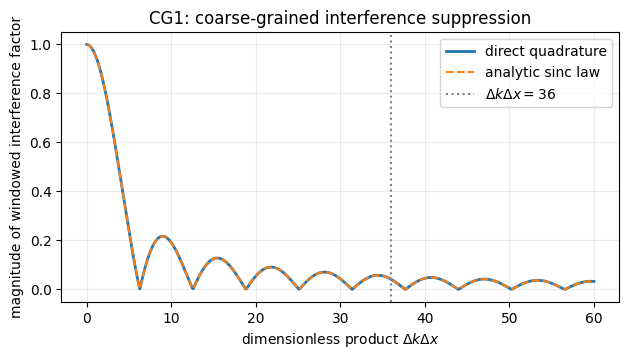

[CG1] Finite-resolution coarse-graining sinc law
- status: ✅ PASS
- criteria:
    * formula_residual_max: <= 5e-5
    * max_tail_suppression_after_36: <= 5e-2
- metrics:
    * formula_residual_max: 6.219815131061623e-07
    * max_tail_suppression_after_36: 0.04901806854495759
- notes: Direct quadrature agrees with the advertised top-hat sinc suppression law.


In [5]:

y = np.linspace(0.0, 60.0, 601)  # y = Delta k * Delta x
u = np.linspace(-0.5, 0.5, 4001)

numeric = []
for yv in y:
    integrand = np.exp(1j * yv * u)
    numeric.append(np.trapezoid(integrand, u))
numeric = np.array(numeric)
formula = np.sinc(y / (2.0 * np.pi))  # sinc(y/2) with numpy normalization

formula_residual_max = float(np.max(np.abs(numeric - formula)))
tail_mask = y >= 36.0
max_tail_suppression_after_36 = float(np.max(np.abs(numeric[tail_mask])))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.plot(y, np.abs(numeric), lw=2, label="direct quadrature")
ax.plot(y, np.abs(formula), lw=1.5, ls="--", label="analytic sinc law")
ax.axvline(36.0, color="gray", ls=":", label=r"$\Delta k \Delta x = 36$")
ax.set_title("CG1: coarse-grained interference suppression")
ax.set_xlabel(r"dimensionless product $\Delta k \Delta x$")
ax.set_ylabel("magnitude of windowed interference factor")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "formula_residual_max": formula_residual_max,
    "max_tail_suppression_after_36": max_tail_suppression_after_36,
}
criteria = {
    "formula_residual_max": "<= 5e-5",
    "max_tail_suppression_after_36": "<= 5e-2",
}
passed = (
    metrics["formula_residual_max"] <= 5e-5
    and metrics["max_tail_suppression_after_36"] <= 5e-2
)
record_gate(
    "CG1",
    "Finite-resolution coarse-graining sinc law",
    passed,
    metrics,
    criteria,
    notes="Direct quadrature agrees with the advertised top-hat sinc suppression law.",
)


## C3 — §2 / Claim C3; §7.1; Gate G3

**Plain-language claim**

If the Born-frequency meter is honest, repeated samples from the correct Born weights should usually pass the KL threshold while samples from the wrong law should fail.

**Formal statement**

`At declared N and seed suite, KL(f||p) <= eps_KL for the correct sampler, with systematic deviations falsifying the meter.`

**Attack mode**

seed sweep + KL gate + adversarial wrong-sampler negative control

**Attack honesty**

This is the paper's own meter turned into an attack: many seeds for the true distribution, then a nearby wrong distribution to make sure the gate has bite.

**Pass / fail criteria**

- `true_pass_fraction`: >= 0.95
- `median_true_kl`: <= 1e-3
- `median_wrong_kl`: >= 1e-2

**This cell cannot prove**

This cell validates the meter on a declared multinomial model; it does not prove every physical apparatus is i.i.d.


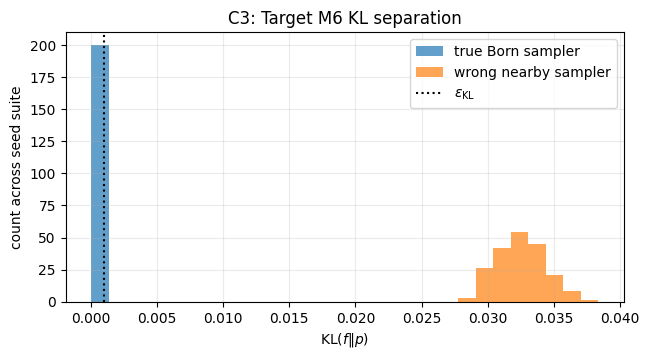

[C3] Target M6 Born-frequency meter
- status: ✅ PASS
- criteria:
    * true_pass_fraction: >= 0.95
    * median_true_kl: <= 1e-3
    * median_wrong_kl: >= 1e-2
- metrics:
    * true_pass_fraction: 1.0
    * median_true_kl: 5.430170354894467e-05
    * median_wrong_kl: 0.03244795175292301
- notes: Covers paper gate G3 with N=20000 and deterministic seed suite size 200.


In [6]:

p = np.array([0.5, 0.2, 0.2, 0.1], dtype=float)
q_wrong = np.array([0.4, 0.3, 0.2, 0.1], dtype=float)
N = 20000
eps_KL = 1e-3
seed_suite = np.arange(20260322, 20260322 + 200, dtype=np.int64)

def kl_divergence(freq: np.ndarray, probs: np.ndarray) -> float:
    mask = freq > 0.0
    return float(np.sum(freq[mask] * np.log(freq[mask] / probs[mask])))

true_kls = []
wrong_kls = []

for seed in seed_suite:
    rng = np.random.default_rng(int(seed))
    counts_true = rng.multinomial(N, p)
    freq_true = counts_true / N
    true_kls.append(kl_divergence(freq_true, p))

    counts_wrong = rng.multinomial(N, q_wrong)
    freq_wrong = counts_wrong / N
    wrong_kls.append(kl_divergence(freq_wrong, p))

true_kls = np.array(true_kls)
wrong_kls = np.array(wrong_kls)

true_pass_fraction = float(np.mean(true_kls <= eps_KL))
median_true_kl = float(np.median(true_kls))
median_wrong_kl = float(np.median(wrong_kls))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
bins = np.linspace(0.0, float(max(np.max(true_kls), np.max(wrong_kls))), 30)
ax.hist(true_kls, bins=bins, alpha=0.7, label="true Born sampler")
ax.hist(wrong_kls, bins=bins, alpha=0.7, label="wrong nearby sampler")
ax.axvline(eps_KL, color="black", ls=":", label=r"$\varepsilon_{\mathrm{KL}}$")
ax.set_title("C3: Target M6 KL separation")
ax.set_xlabel(r"$\mathrm{KL}(f\|p)$")
ax.set_ylabel("count across seed suite")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "true_pass_fraction": true_pass_fraction,
    "median_true_kl": median_true_kl,
    "median_wrong_kl": median_wrong_kl,
}
criteria = {
    "true_pass_fraction": ">= 0.95",
    "median_true_kl": "<= 1e-3",
    "median_wrong_kl": ">= 1e-2",
}
passed = (
    metrics["true_pass_fraction"] >= 0.95
    and metrics["median_true_kl"] <= 1e-3
    and metrics["median_wrong_kl"] >= 1e-2
)
record_gate(
    "C3",
    "Target M6 Born-frequency meter",
    passed,
    metrics,
    criteria,
    notes=f"Covers paper gate G3 with N={N} and deterministic seed suite size {len(seed_suite)}.",
)


## C4 — §2 / Claim C4; §7.2-7.3

**Plain-language claim**

The expected KL divergence should fall like (d-1)/(2N). If the empirical mean scales differently, the paper's planning law is wrong.

**Formal statement**

`In the large-N regime, E[KL(f||p)] ~ (d-1)/(2N).`

**Attack mode**

sample-size sweep + Monte Carlo mean + log-log slope check + wrong-scaling negative control

**Attack honesty**

This cell attacks both the absolute prefactor and the 1/N scaling, then compares it to an obviously wrong 1/N^2 law.

**Pass / fail criteria**

- `loglog_slope`: between -1.1 and -0.9
- `max_relative_error_to_prediction`: <= 0.1
- `wrong_scaling_sse_ratio`: >= 10

**This cell cannot prove**

This cell is still a finite Monte Carlo study; it does not replace an asymptotic theorem proof.


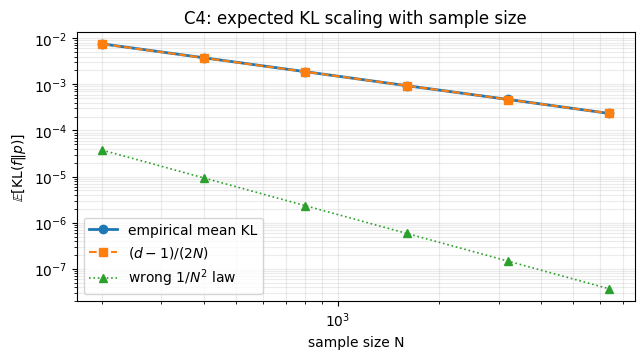

[C4] Expected KL scaling law
- status: ✅ PASS
- criteria:
    * loglog_slope: between -1.1 and -0.9
    * max_relative_error_to_prediction: <= 0.1
    * wrong_scaling_sse_ratio: >= 10
- metrics:
    * loglog_slope: -1.0026225554107102
    * max_relative_error_to_prediction: 0.007363463867153993
    * wrong_scaling_sse_ratio: 23879.851943724556
- notes: Monte Carlo mean over reps=20000 per N; wrong 1/N^2 scaling is rejected decisively.


In [7]:

p = np.array([0.1, 0.2, 0.3, 0.4], dtype=float)
d = len(p)
Ns = np.array([200, 400, 800, 1600, 3200, 6400], dtype=int)
reps = 20000
rng = np.random.default_rng(20260322)

def kl_rows(counts: np.ndarray, probs: np.ndarray) -> np.ndarray:
    freq = counts / counts.sum(axis=1, keepdims=True)
    mask = freq > 0.0
    return np.sum(np.where(mask, freq * np.log(freq / probs), 0.0), axis=1)

empirical_mean_kl = []
for N in Ns:
    counts = rng.multinomial(N, p, size=reps)
    empirical_mean_kl.append(float(np.mean(kl_rows(counts, p))))
empirical_mean_kl = np.array(empirical_mean_kl)

prediction = (d - 1) / (2.0 * Ns)
wrong_prediction = (d - 1) / (2.0 * Ns ** 2)

loglog_slope = float(np.polyfit(np.log(Ns), np.log(empirical_mean_kl), 1)[0])
max_relative_error_to_prediction = float(np.max(np.abs(empirical_mean_kl - prediction) / prediction))
sse_right = float(np.sum((empirical_mean_kl - prediction) ** 2))
sse_wrong = float(np.sum((empirical_mean_kl - wrong_prediction) ** 2))
wrong_scaling_sse_ratio = float(sse_wrong / sse_right)

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.loglog(Ns, empirical_mean_kl, marker="o", lw=2, label="empirical mean KL")
ax.loglog(Ns, prediction, marker="s", ls="--", lw=1.5, label=r"$(d-1)/(2N)$")
ax.loglog(Ns, wrong_prediction, marker="^", ls=":", lw=1.2, label=r"wrong $1/N^2$ law")
ax.set_title("C4: expected KL scaling with sample size")
ax.set_xlabel("sample size N")
ax.set_ylabel(r"$\mathbb{E}[\mathrm{KL}(f\|p)]$")
ax.legend()
ax.grid(alpha=0.25, which="both")
plt.show()

metrics = {
    "loglog_slope": loglog_slope,
    "max_relative_error_to_prediction": max_relative_error_to_prediction,
    "wrong_scaling_sse_ratio": wrong_scaling_sse_ratio,
}
criteria = {
    "loglog_slope": "between -1.1 and -0.9",
    "max_relative_error_to_prediction": "<= 0.1",
    "wrong_scaling_sse_ratio": ">= 10",
}
passed = (
    -1.1 <= metrics["loglog_slope"] <= -0.9
    and metrics["max_relative_error_to_prediction"] <= 0.1
    and metrics["wrong_scaling_sse_ratio"] >= 10.0
)
record_gate(
    "C4",
    "Expected KL scaling law",
    passed,
    metrics,
    criteria,
    notes=f"Monte Carlo mean over reps={reps} per N; wrong 1/N^2 scaling is rejected decisively.",
)


## R1 — §8 Gate G4 robustness under perturbations

**Plain-language claim**

A measurement channel that falls apart under tiny perturbations is not a usable instrument. Small Hamiltonian tilts should cause only small pointer and probability drift.

**Formal statement**

`For ||delta H_SE||/||H_SE|| <= eta, induced changes in pointer projectors and Born weights remain within stated tolerances.`

**Attack mode**

operator perturbation sweep + projector-drift metric + Born-weight drift metric + large-perturbation negative control

**Attack honesty**

This cell perturbs the measurement coupling continuously, measures both basis drift and probability drift, and checks that small tilts stay small while a large tilt does not.

**Pass / fail criteria**

- `small_delta_projector_drift_max`: <= 3e-2
- `small_delta_prob_drift_max`: <= 5e-3
- `large_delta_prob_drift_min`: >= 5e-2

**This cell cannot prove**

This cell validates a concrete perturbative robustness contract, not every possible detector architecture.


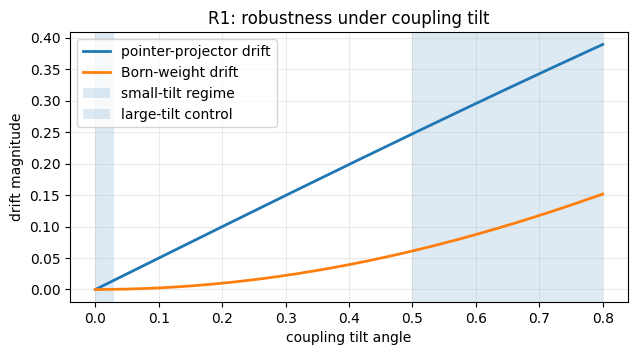

[R1] Robustness under small coupling perturbations
- status: ✅ PASS
- criteria:
    * small_delta_projector_drift_max: <= 3e-2
    * small_delta_prob_drift_max: <= 5e-3
    * large_delta_prob_drift_min: >= 5e-2
- metrics:
    * small_delta_projector_drift_max: 0.014999437506328098
    * small_delta_prob_drift_max: 0.00022498312550624187
    * large_delta_prob_drift_min: 0.06120871905481373
- notes: Covers paper gate G4 by separating the small-tilt instrument regime from a large-tilt negative control.


In [8]:

sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
rho_ref = np.array([[1.0, 0.0], [0.0, 0.0]], dtype=complex)

def eigen_projectors(H: np.ndarray) -> List[np.ndarray]:
    evals, evecs = np.linalg.eigh(H)
    order = np.argsort(evals)[::-1]
    evecs = evecs[:, order]
    return [np.outer(evecs[:, i], evecs[:, i].conj()) for i in range(H.shape[0])]

def born_probabilities(projectors: List[np.ndarray], rho: np.ndarray) -> np.ndarray:
    return np.array([float(np.real(np.trace(P @ rho))) for P in projectors])

theta_grid = np.linspace(0.0, 0.8, 401)
base_projectors = eigen_projectors(sigma_z)
base_probs = born_probabilities(base_projectors, rho_ref)

projector_drift = []
probability_drift = []

for theta in theta_grid:
    H_tilt = math.cos(theta) * sigma_z + math.sin(theta) * sigma_x
    tilted_projectors = eigen_projectors(H_tilt)
    projector_drift.append(max(float(np.linalg.norm(tilted_projectors[i] - base_projectors[i], ord=2)) for i in range(2)))
    probability_drift.append(float(np.max(np.abs(born_probabilities(tilted_projectors, rho_ref) - base_probs))))

projector_drift = np.array(projector_drift)
probability_drift = np.array(probability_drift)

small_mask = theta_grid <= 0.03
large_mask = theta_grid >= 0.5

small_delta_projector_drift_max = float(np.max(projector_drift[small_mask]))
small_delta_prob_drift_max = float(np.max(probability_drift[small_mask]))
large_delta_prob_drift_min = float(np.min(probability_drift[large_mask]))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.plot(theta_grid, projector_drift, lw=2, label="pointer-projector drift")
ax.plot(theta_grid, probability_drift, lw=2, label="Born-weight drift")
ax.axvspan(0.0, 0.03, alpha=0.15, label="small-tilt regime")
ax.axvspan(0.5, 0.8, alpha=0.15, label="large-tilt control")
ax.set_title("R1: robustness under coupling tilt")
ax.set_xlabel("coupling tilt angle")
ax.set_ylabel("drift magnitude")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

metrics = {
    "small_delta_projector_drift_max": small_delta_projector_drift_max,
    "small_delta_prob_drift_max": small_delta_prob_drift_max,
    "large_delta_prob_drift_min": large_delta_prob_drift_min,
}
criteria = {
    "small_delta_projector_drift_max": "<= 3e-2",
    "small_delta_prob_drift_max": "<= 5e-3",
    "large_delta_prob_drift_min": ">= 5e-2",
}
passed = (
    metrics["small_delta_projector_drift_max"] <= 3e-2
    and metrics["small_delta_prob_drift_max"] <= 5e-3
    and metrics["large_delta_prob_drift_min"] >= 5e-2
)
record_gate(
    "R1",
    "Robustness under small coupling perturbations",
    passed,
    metrics,
    criteria,
    notes="Covers paper gate G4 by separating the small-tilt instrument regime from a large-tilt negative control.",
)


## L0 — Final results ledger

**Plain-language view**

The notebook closes by checking three things:

- every declared claim was actually attacked
- the paper-level gates `G1–G4` were covered by the appropriate claim cells
- the reader can see the paper-wide pass/fail surface in one place

**Pass / fail rule**

Pass only if no declared claim is missing and no advertised paper gate is left uncovered.


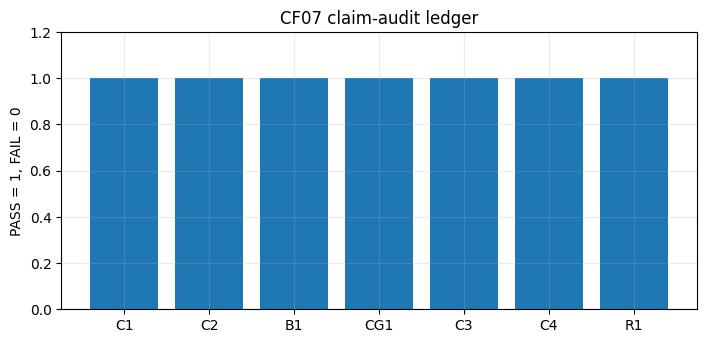

Ledger summary by gate:
 -  M0 | PASS | Compact manifest integrity
 -  C1 | PASS | Pointer stability / einselection residual
 -  C2 | PASS | Decoherence threshold crossing
 -  B1 | PASS | Born-rule narrowing step inside the power family
 - CG1 | PASS | Finite-resolution coarse-graining sinc law
 -  C3 | PASS | Target M6 Born-frequency meter
 -  C4 | PASS | Expected KL scaling law
 -  R1 | PASS | Robustness under small coupling perturbations

Declared claim ids: ['C1', 'C2', 'B1', 'CG1', 'C3', 'C4', 'R1']
Executed claim ids: ['C1', 'C2', 'B1', 'CG1', 'C3', 'C4', 'R1']
Missing claim audits: []
Advertised paper gates: ['G1', 'G2', 'G3', 'G4']
Covered paper gates: ['G1', 'G2', 'G3', 'G4']
Uncovered paper gates: []
[L0] Final claim and gate coverage ledger
- status: ✅ PASS
- criteria:
    * ledger_gate_count: >= 1
    * unique_gate_count_equals_ledger_gate_count: True
    * pass_count_plus_fail_count_equals_ledger_gate_count: True
    * missing_claim_audit_count: 0
    * uncovered_paper_gat

In [9]:
ledger_gate_ids = [g.gate_id for g in LEDGER]
pass_count = sum(int(g.passed) for g in LEDGER)
fail_count = len(LEDGER) - pass_count

declared_claim_ids = [claim["claim_id"] for claim in PAPER_SPEC["claims"]]
executed_claim_ids = [gid for gid in ledger_gate_ids if gid in declared_claim_ids]
missing_claim_audits = sorted(set(declared_claim_ids) - set(executed_claim_ids))

paper_gate_ids = [g["gate_id"] for g in PAPER_SPEC["paper_validation_gates"]]
covered_paper_gates = sorted({pg for cid in executed_claim_ids for pg in CLAIM_TO_PAPER_GATES.get(cid, [])})
uncovered_paper_gates = sorted(set(paper_gate_ids) - set(covered_paper_gates))

fig, ax = plt.subplots(figsize=(8.2, 3.6))
claim_status = [g for g in LEDGER if g.gate_id in declared_claim_ids]
ax.bar([g.gate_id for g in claim_status], [1 if g.passed else 0 for g in claim_status])
ax.set_ylim(0, 1.2)
ax.set_title("CF07 claim-audit ledger")
ax.set_ylabel("PASS = 1, FAIL = 0")
ax.grid(alpha=0.25)
plt.show()

print("Ledger summary by gate:")
for gate in LEDGER:
    status = "PASS" if gate.passed else "FAIL"
    print(f" - {gate.gate_id:>3} | {status:<4} | {gate.gate_name}")

print("\nDeclared claim ids:", declared_claim_ids)
print("Executed claim ids:", executed_claim_ids)
print("Missing claim audits:", missing_claim_audits)
print("Advertised paper gates:", paper_gate_ids)
print("Covered paper gates:", covered_paper_gates)
print("Uncovered paper gates:", uncovered_paper_gates)

metrics = {
    "ledger_gate_count": len(LEDGER),
    "unique_gate_count": len(set(ledger_gate_ids)),
    "pass_count": pass_count,
    "fail_count": fail_count,
    "declared_claim_count": len(declared_claim_ids),
    "executed_claim_count": len(executed_claim_ids),
    "missing_claim_audit_count": len(missing_claim_audits),
    "advertised_paper_gate_count": len(paper_gate_ids),
    "covered_paper_gate_count": len(covered_paper_gates),
    "uncovered_paper_gate_count": len(uncovered_paper_gates),
}
criteria = {
    "ledger_gate_count": ">= 1",
    "unique_gate_count_equals_ledger_gate_count": True,
    "pass_count_plus_fail_count_equals_ledger_gate_count": True,
    "missing_claim_audit_count": 0,
    "uncovered_paper_gate_count": 0,
}
passed = (
    len(LEDGER) >= 1
    and len(set(ledger_gate_ids)) == len(LEDGER)
    and (pass_count + fail_count == len(LEDGER))
    and len(missing_claim_audits) == 0
    and len(uncovered_paper_gates) == 0
)
record_gate(
    "L0",
    "Final claim and gate coverage ledger",
    passed,
    metrics,
    criteria,
    notes="Full paper text intentionally omitted; the notebook closes on executable claim coverage and paper-gate coverage only.",
)
